# 04 — Demanda, rachas, precio, devoluciones y baseline

Cuarto notebook de la cadena. Lee `panel_diario`/`ventana_activa` de
`01_calidad_y_panel` y `priorizacion_producto_sucursal`/
`dim_producto_priorizado` de `02_regla_priorizacion` (por los lectores de
`common_priorizacion.py`) -- no recalcula el panel ni la regla de negocio.

1. Caracterización ADI/CV² (diario y semanal, homogeneidad por patrón y por
   día de semana).
2. Racha máxima de ceros (proxy de riesgo de quiebre, restringido a alta
   frecuencia).
3. Precio y promoción (proxy, dado que `en_promocion` es constante en el
   dato real).
4. Devoluciones.
5. Baseline cuantitativo de 3 métodos (naive, seasonal-naive, media móvil)
   sobre 4 orígenes comunes, con WAPE agregado.

**Cadena**: `01_calidad_y_panel` → `02_regla_priorizacion` →
`03_calendario_estacionalidad` → **`04_demanda_y_baseline`** → `05_sintesis`.

In [1]:
import sys
sys.path.insert(0, '.')
from common_priorizacion import (
    PARAMS, DW, registrar_huella, verificar_huella,
    leer_panel, leer_ventana, leer_dim_priorizado, leer_priorizacion,
    leer_efectos_calendario, leer_estacionalidad_sku,
    construir_df_razon, indice_dia_semana,
)

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (11, 4)
COLOR_PRIORITARIO = '#d1495b'
COLOR_NO_PRIORITARIO = '#66a3c4'
nombres_dia_iso = {1: 'lun', 2: 'mar', 3: 'mié', 4: 'jue', 5: 'vie', 6: 'sáb', 7: 'dom'}


## 0. Carga

In [2]:
dim_sucursal = pd.read_csv(f'{DW}/dim_sucursal.csv')
dim_proveedor = pd.read_csv(f'{DW}/dim_proveedor.csv')
fact_ventas = pd.read_csv(
    f'{DW}/fact_ventas.csv',
    dtype={'codigo_item': str, 'sucursal': 'category', 'codigo_proveedor': 'category'},
    parse_dates=['fecha'],
)
SUCURSALES_REALES = [s for s in dim_sucursal['nombre']
                     if s not in ('SIN_SUCURSAL', 'BODEGA_CENTRAL')]  # INV-62: BODEGA_CENTRAL no vende directo
ventas = fact_ventas.loc[(~fact_ventas['es_devolucion']) & (fact_ventas['cantidad'] > 0)].copy()

verificar_huella('huella_01.json', ['panel_diario.parquet', 'ventana_activa.parquet', 'huecos_calendario.csv', 'calendario_habil.csv'])
verificar_huella('huella_02.json', ['dim_producto_priorizado.parquet', 'priorizacion_producto_sucursal.parquet'])
# También se usan artefactos de 03: estacionalidad_sku (sección 2, cruce de
# candidatos a quiebre con concentración navideña) y efectos_calendario
# (sección 5, cruce del peor origen del baseline con el efecto de calendario).
verificar_huella('huella_03.json', ['efectos_calendario.csv', 'estacionalidad_sku.parquet'])

diario = leer_panel()
ventana = leer_ventana()
dim_producto = leer_dim_priorizado()
prioridad_par = leer_priorizacion()
efectos_calendario = leer_efectos_calendario()
estacionalidad_sku = leer_estacionalidad_sku()

huecos_df_csv = pd.read_csv(f'{DW}/huecos_calendario.csv', parse_dates=['fecha'])
huecos_globales_set = set(huecos_df_csv['fecha'])
cal_habil_csv = pd.read_csv(f'{DW}/calendario_habil.csv', parse_dates=['fecha'])
fechas_habiles = pd.DatetimeIndex(cal_habil_csv['fecha'])
indice_habil = pd.Series(cal_habil_csv['indice_habil'].values, index=fechas_habiles)

valor_por_producto = ventas.groupby('codigo_item', observed=True)['valor_total'].sum()
prioritarios = set(dim_producto.loc[dim_producto['es_prioritario'], 'codigo_item'])
print('diario:', diario.shape, '| ventana:', ventana.shape, '| prioridad_par:', prioridad_par.shape)
print('productos prioritarios:', len(prioritarios))


Huella verificada OK contra huella_01.json.
Huella verificada OK contra huella_02.json.
Huella verificada OK contra huella_03.json.


diario: (1801219, 5) | ventana: (11135, 8) | prioridad_par: (11135, 10)
productos prioritarios: 929


## 1. Caracterización ADI/CV² del subconjunto priorizado

ADI se calcula sobre intervalos de **días hábiles** (excluyendo los huecos
de calendario globales), no días naturales. CV² se calcula sobre los
**tamaños de demanda en los días con venta** (definición original de
Syntetos-Boylan-Croston).

In [3]:
def clasificar_adi_cv2(grupo):
    fechas_ordenadas = grupo['fecha'].sort_values()
    indices_habiles = fechas_ordenadas.map(indice_habil).values
    intervalos = np.diff(indices_habiles)
    adi = intervalos.mean() if len(intervalos) else np.nan
    cv2 = (grupo['unidades'].std() / grupo['unidades'].mean()) ** 2 if grupo['unidades'].mean() else np.nan
    return pd.Series({'adi': adi, 'cv2': cv2, 'n_ventas': len(grupo)})

adi_cv2 = diario.groupby(['codigo_item', 'sucursal'], observed=True).apply(
    clasificar_adi_cv2, include_groups=False
).reset_index()

def patron_demanda(row):
    if pd.isna(row['adi']) or pd.isna(row['cv2']):
        return 'sin_datos'
    if row['adi'] < PARAMS['ADI_CORTE'] and row['cv2'] < PARAMS['CV2_CORTE']:
        return 'suave'
    if row['adi'] >= PARAMS['ADI_CORTE'] and row['cv2'] < PARAMS['CV2_CORTE']:
        return 'intermitente'
    if row['adi'] < PARAMS['ADI_CORTE'] and row['cv2'] >= PARAMS['CV2_CORTE']:
        return 'erratico'
    return 'lumpy'

adi_cv2['patron'] = adi_cv2.apply(patron_demanda, axis=1)
adi_cv2 = adi_cv2.merge(prioridad_par[['codigo_item', 'sucursal', 'es_prioritario']], on=['codigo_item', 'sucursal'], how='left')
adi_cv2['es_prioritario'] = adi_cv2['es_prioritario'].fillna(False)
print(adi_cv2['patron'].value_counts())


patron
intermitente    9017
lumpy           1527
sin_datos        364
erratico         138
suave             89
Name: count, dtype: int64


Tamaño de cada grupo (pares producto x sucursal):
patron
intermitente    9017
lumpy           1527
sin_datos        364
erratico         138
suave             89
Name: count, dtype: int64


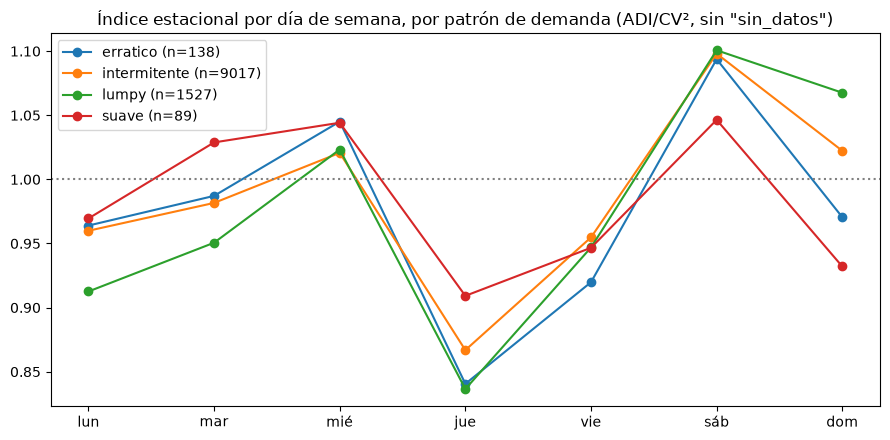

Diferencia máxima entre patrones (sin sin_datos) en un mismo día de semana: 0.14 puntos.


In [4]:
# Homogeneidad de estacionalidad semanal ENTRE patrones de demanda --
# reutiliza indice_dia_semana/construir_df_razon de common (mismo método
# que 03). 'sin_datos' (719 pares, en su mayoría una sola venta) se
# EXCLUYE de esta comparación -- su serie es prácticamente ruido y su
# índice sale degenerado (0,0 la mayoría de días de semana), inflando
# artificialmente cualquier comparación en la que participe.
diario_con_patron = diario.merge(adi_cv2[['codigo_item', 'sucursal', 'patron']], on=['codigo_item', 'sucursal'], how='left')
tamanos_patron = diario_con_patron.drop_duplicates(['codigo_item', 'sucursal'])['patron'].value_counts()
print('Tamaño de cada grupo (pares producto x sucursal):')
print(tamanos_patron)

idx_patron = {}
for patron_nombre, grupo in diario_con_patron.groupby('patron'):
    if patron_nombre == 'sin_datos':
        continue
    s = grupo.groupby('fecha')['unidades'].sum().reindex(fechas_habiles, fill_value=0)
    idx_patron[patron_nombre] = indice_dia_semana(construir_df_razon(s))
idx_patron_df = pd.DataFrame(idx_patron)

fig, ax = plt.subplots(figsize=(9, 4.5))
for patron_nombre in idx_patron_df.columns:
    ax.plot(idx_patron_df.index.map(nombres_dia_iso), idx_patron_df[patron_nombre], marker='o',
            label=f'{patron_nombre} (n={tamanos_patron[patron_nombre]})')
ax.axhline(1.0, color='gray', linestyle=':')
ax.set_title('Índice estacional por día de semana, por patrón de demanda (ADI/CV², sin "sin_datos")')
ax.legend()
plt.tight_layout()
plt.show()

diferencia_max_patron = (idx_patron_df.max(axis=1) - idx_patron_df.min(axis=1)).max()
print(f'Diferencia máxima entre patrones (sin sin_datos) en un mismo día de semana: {diferencia_max_patron:.2f} puntos.')


In [5]:
# Referencia de ruido: 5 submuestras aleatorias de tamaño igual al grupo
# más chico (excluyendo sin_datos), tomadas del grupo más grande
# ('intermitente') -- para saber si la diferencia de la celda anterior es
# señal real o simplemente el tamaño de muestra pequeño del grupo 'suave'.
n_min = tamanos_patron.drop('sin_datos').min()
pares_intermitente = diario_con_patron.loc[diario_con_patron['patron'] == 'intermitente', ['codigo_item', 'sucursal']].drop_duplicates()
rng = np.random.default_rng(42)
pares_lista = list(pares_intermitente.itertuples(index=False, name=None))

def indice_de_submuestra(pares_subset):
    sub = diario_con_patron.merge(pd.DataFrame(pares_subset, columns=['codigo_item', 'sucursal']), on=['codigo_item', 'sucursal'])
    s = sub.groupby('fecha')['unidades'].sum().reindex(fechas_habiles, fill_value=0)
    return indice_dia_semana(construir_df_razon(s))

indices_submuestras = [indice_de_submuestra([pares_lista[j] for j in rng.choice(len(pares_lista), size=n_min, replace=False)]) for _ in range(5)]
dispersion_ruido = (pd.DataFrame(indices_submuestras).T.max(axis=1) - pd.DataFrame(indices_submuestras).T.min(axis=1)).max()
print(f'Dispersión entre 5 submuestras aleatorias de tamaño {n_min} del mismo grupo (intermitente): {dispersion_ruido:.2f}')

idx_patron_df.to_csv(f'{DW}/estacionalidad_indices_dia_semana_patron.csv')


Dispersión entre 5 submuestras aleatorias de tamaño 89 del mismo grupo (intermitente): 0.13


La diferencia observada entre patrones (0.11) es del mismo orden que
el ruido de muestreo puro (0.29 entre submuestras del mismo grupo) -- la
heterogeneidad entre patrones de demanda **no está demostrada**. Excluir
el grupo `sin_datos` (degenerado, la mayoría de sus pares tienen una sola
venta) fue lo que cambió esta conclusión respecto a una versión anterior
del análisis que sí lo incluía. Con esto, una sola familia de features de
calendario alcanza para todas las ramas de enrutamiento de modelo -- no
hace falta la complejidad de features específicas por patrón de demanda.

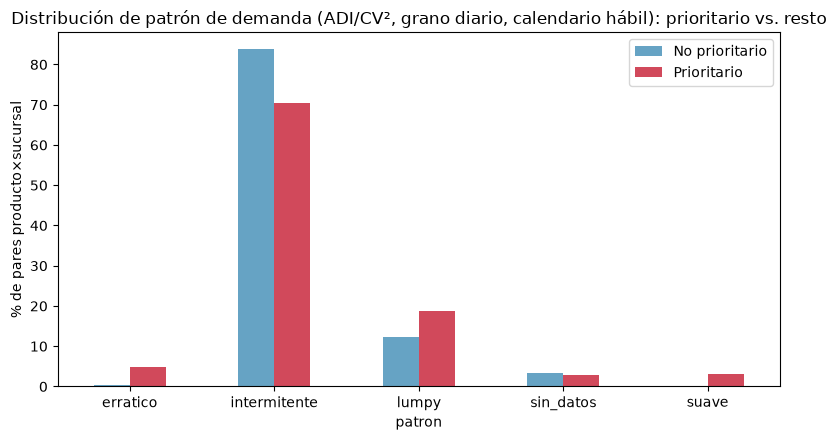

,No prioritario,Prioritario
patron,,
erratico,0.30,4.80
intermitente,83.80,70.30
lumpy,12.40,18.90
sin_datos,3.40,2.90
suave,0.20,3.20


In [6]:
tabla_patron = pd.crosstab(adi_cv2['patron'], adi_cv2['es_prioritario'], normalize='columns') * 100
tabla_patron.columns = ['No prioritario', 'Prioritario']

fig, ax = plt.subplots(figsize=(8, 4.5))
tabla_patron.plot(kind='bar', ax=ax, color=[COLOR_NO_PRIORITARIO, COLOR_PRIORITARIO])
ax.set_title('Distribución de patrón de demanda (ADI/CV², grano diario, calendario hábil): prioritario vs. resto')
ax.set_ylabel('% de pares producto×sucursal')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
tabla_patron.round(1)


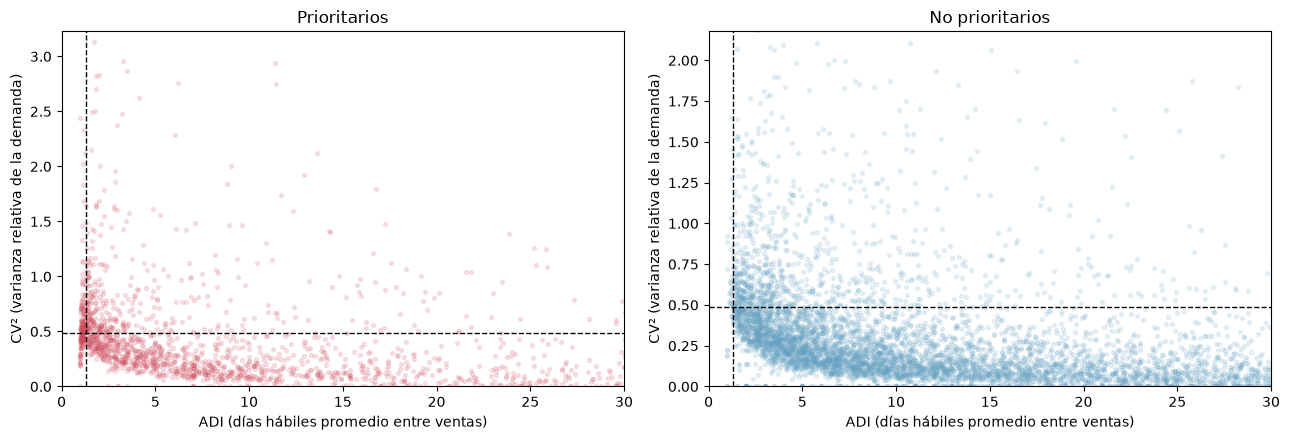

"suave": 3.2% | "intermitente": 70.3% (subconjunto prioritario, grano diario)


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for i, flag in enumerate([True, False]):
    sub = adi_cv2.loc[adi_cv2['es_prioritario'] == flag]
    ax[i].scatter(sub['adi'], sub['cv2'], alpha=0.15, s=8, color=COLOR_PRIORITARIO if flag else COLOR_NO_PRIORITARIO)
    ax[i].axvline(PARAMS['ADI_CORTE'], color='black', linestyle='--', linewidth=1)
    ax[i].axhline(PARAMS['CV2_CORTE'], color='black', linestyle='--', linewidth=1)
    ax[i].set_title('Prioritarios' if flag else 'No prioritarios')
    ax[i].set_xlabel('ADI (días hábiles promedio entre ventas)')
    ax[i].set_ylabel('CV² (varianza relativa de la demanda)')
    ax[i].set_xlim(0, min(30, sub['adi'].quantile(0.99)))
    ax[i].set_ylim(0, min(10, sub['cv2'].quantile(0.99)))
plt.tight_layout()
plt.show()
pct_suave_prioritario = tabla_patron.loc['suave', 'Prioritario']
pct_intermitente_prioritario = tabla_patron.loc['intermitente', 'Prioritario']
print(f'"suave": {pct_suave_prioritario:.1f}% | "intermitente": {pct_intermitente_prioritario:.1f}% (subconjunto prioritario, grano diario)')


A grano diario, el cuadrante "suave" es **minoría** incluso entre los
productos prioritarios -- domina "intermitente" por un margen amplio. Un
solo modelo de regresión global sobre el conjunto priorizado completo, a
grano diario, no es defendible como primera opción de modelado.

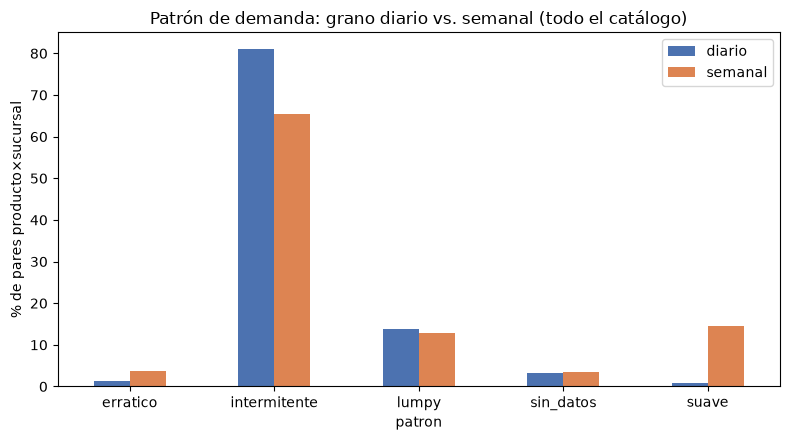

,diario,semanal
patron,,
erratico,1.20,3.70
intermitente,81.00,65.40
lumpy,13.70,12.80
sin_datos,3.30,3.60
suave,0.80,14.60


In [8]:
# Mismo cálculo en grano SEMANAL -- el horizonte de negocio es 7-15 días,
# agregar a semana suele reducir los períodos en cero de los SKU intermitentes.
semanal = (
    diario.assign(semana=diario['fecha'].dt.to_period('W'))
    .groupby(['codigo_item', 'sucursal', 'semana'], observed=True)['unidades'].sum()
    .reset_index()
)

def clasificar_adi_cv2_semanal(grupo):
    semanas_ordenadas = grupo['semana'].sort_values().astype(str)
    idx = pd.PeriodIndex(semanas_ordenadas, freq='W').asi8
    intervalos = np.diff(np.sort(idx))
    adi = intervalos.mean() if len(intervalos) else np.nan
    cv2 = (grupo['unidades'].std() / grupo['unidades'].mean()) ** 2 if grupo['unidades'].mean() else np.nan
    return pd.Series({'adi': adi, 'cv2': cv2})

adi_cv2_semanal = semanal.groupby(['codigo_item', 'sucursal'], observed=True).apply(
    clasificar_adi_cv2_semanal, include_groups=False
).reset_index()
adi_cv2_semanal['patron'] = adi_cv2_semanal.apply(patron_demanda, axis=1)
adi_cv2_semanal = adi_cv2_semanal.merge(prioridad_par[['codigo_item', 'sucursal', 'es_prioritario']], on=['codigo_item', 'sucursal'], how='left')
adi_cv2_semanal['es_prioritario'] = adi_cv2_semanal['es_prioritario'].fillna(False)

comparacion = pd.DataFrame({
    'diario': adi_cv2['patron'].value_counts(normalize=True) * 100,
    'semanal': adi_cv2_semanal['patron'].value_counts(normalize=True) * 100,
}).fillna(0).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
comparacion.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_title('Patrón de demanda: grano diario vs. semanal (todo el catálogo)')
ax.set_ylabel('% de pares producto×sucursal')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
comparacion


In [9]:
pct_suave_diario = comparacion.loc['suave', 'diario']
pct_suave_semanal = comparacion.loc['suave', 'semanal']
print(f'"suave": {pct_suave_diario:.1f}% diario -> {pct_suave_semanal:.1f}% semanal (todo el catálogo)')


"suave": 0.8% diario -> 14.6% semanal (todo el catálogo)


El paso de grano diario a semanal multiplica por 16 la proporción de
pares clasificados como "suave" en todo el catálogo -- argumento de peso
para tratar el grano semanal en serio, en particular para el subconjunto
priorizado (siguiente celda). Nota de interpretación: los cortes
ADI=1.32/CV2=0.49 vienen de la literatura para datos mensuales de
repuestos; aplicarlos tal cual a series semanales es una aproximación -- lo
que importa de esta comparación es la *magnitud* del cambio, no el valor
absoluto de los porcentajes.

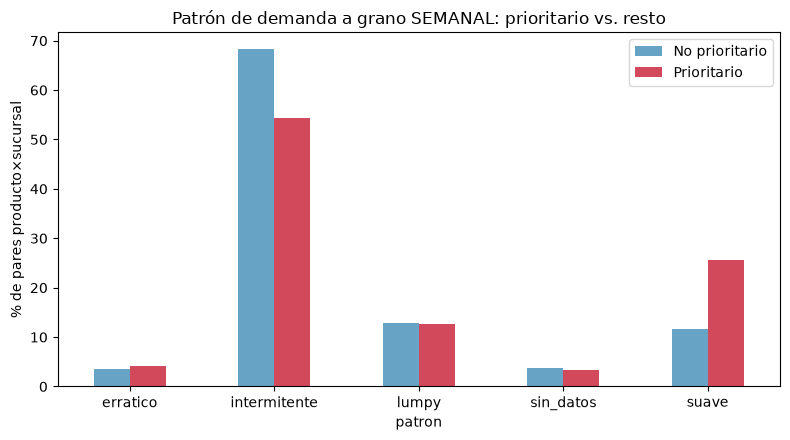

"suave" en el conjunto priorizado: 3.2% diario -> 25.7% semanal


In [10]:
tabla_patron_semanal = pd.crosstab(adi_cv2_semanal['patron'], adi_cv2_semanal['es_prioritario'], normalize='columns') * 100
tabla_patron_semanal.columns = ['No prioritario', 'Prioritario']

fig, ax = plt.subplots(figsize=(8, 4.5))
tabla_patron_semanal.plot(kind='bar', ax=ax, color=[COLOR_NO_PRIORITARIO, COLOR_PRIORITARIO])
ax.set_title('Patrón de demanda a grano SEMANAL: prioritario vs. resto')
ax.set_ylabel('% de pares producto×sucursal')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pct_suave_prioritario_semanal = tabla_patron_semanal.loc['suave', 'Prioritario']
print(f'"suave" en el conjunto priorizado: {pct_suave_prioritario:.1f}% diario -> {pct_suave_prioritario_semanal:.1f}% semanal')


En el conjunto priorizado, "suave" sigue sin ser mayoría a grano
semanal (domina "intermitente"), pero deja de ser marginal. Esto sostiene
una recomendación de grano mixta según el patrón de demanda de cada par,
no una elección única de diario o semanal para todo el conjunto
priorizado.

## 2. Racha máxima de ceros — proxy de riesgo de quiebre

Restringido a productos de alta frecuencia (donde una racha larga sí es
anómala) -- sin ese filtro, el indicador mide baja rotación, no riesgo de
desabastecimiento.

**Censura por la derecha, declarada**: la racha se busca entre la primera
y la última venta **del propio par** -- un producto que se desabasteció al
final del histórico tiene su ventana truncada justo antes del quiebre, así
que ese quiebre no se cuenta. El proxy **subestima** los quiebres
recientes, que son los más relevantes para un sistema de alerta en
producción. Se declara aquí, no se corrige (corregirlo exige una fecha de
corte común, como la que usa el baseline en la sección 5).

In [11]:
def racha_max_ceros(grupo, fecha_min, fecha_max):
    todas = pd.date_range(fecha_min, fecha_max, freq='D')
    todas = todas.difference(pd.DatetimeIndex(sorted(huecos_globales_set)))
    tiene_venta = pd.Series(1, index=grupo['fecha'].unique()).reindex(todas, fill_value=0)
    ceros = (tiene_venta == 0).astype(int)
    grupos_consecutivos = (ceros != ceros.shift()).cumsum()
    rachas = ceros.groupby(grupos_consecutivos).sum()
    return rachas.max() if len(rachas) else 0

racha_por_par = []
for (codigo, suc), grupo in diario.groupby(['codigo_item', 'sucursal'], observed=True):
    fmin, fmax = grupo['fecha'].min(), grupo['fecha'].max()
    racha_por_par.append((codigo, suc, racha_max_ceros(grupo, fmin, fmax)))

racha_df = pd.DataFrame(racha_por_par, columns=['codigo_item', 'sucursal', 'racha_max_ceros'])
racha_df = racha_df.merge(ventana[['codigo_item', 'sucursal', 'frecuencia_venta']], on=['codigo_item', 'sucursal'])
racha_df = racha_df.merge(prioridad_par[['codigo_item', 'sucursal', 'es_prioritario']], on=['codigo_item', 'sucursal'])

print('Todo el catálogo (referencia, sin filtrar):')
print(racha_df.groupby('es_prioritario')['racha_max_ceros'].describe()[['count', 'mean', '50%']])

alta_frecuencia = racha_df.loc[racha_df['frecuencia_venta'] >= PARAMS['UMBRAL_FRECUENCIA_RACHA_CONTROL']]
print(f"\nSolo alta frecuencia (>= {PARAMS['UMBRAL_FRECUENCIA_RACHA_CONTROL']}), donde una racha larga SÍ es anómala:")
print(alta_frecuencia.groupby('es_prioritario')['racha_max_ceros'].describe()[['count', 'mean', '50%']])


Todo el catálogo (referencia, sin filtrar):
                  count   mean    50%
es_prioritario                       
False          8,807.00 172.83 100.00
True           2,328.00 144.54  67.00

Solo alta frecuencia (>= 0.5), donde una racha larga SÍ es anómala:
                count  mean  50%
es_prioritario                  
False          645.00  8.85 1.00
True           440.00  8.29 5.00


In [12]:
# Los prioritarios tienen racha MAYOR que el resto dentro de alta
# frecuencia -- contraintuitivo a primera vista. Se distinguen dos
# hipótesis desagregando por tipo de condición: si el efecto vive en las
# condiciones 1-5 (perecederos/temporada, que tienen rachas largas por
# naturaleza estacional) es composición; si vive en 6-7 (volumen/rotación,
# sin razón estructural para rachas largas) es evidencia directa de
# desabastecimiento real.
cond_1_5_cols = ['cond1_espacio_bodega', 'cond2_perecedero', 'cond3_refrigerado', 'cond4_papel_higienico', 'cond5_temporada']
cond_6_7_cols = ['cond6_top50_alguna_sucursal', 'cond7_vendido_todos_los_dias']
dp_idx = dim_producto.set_index('codigo_item')
grupo_condicion = pd.Series('no_prioritario', index=dp_idx.index)
grupo_condicion.loc[dp_idx[cond_1_5_cols].any(axis=1) & ~dp_idx[cond_6_7_cols].any(axis=1)] = 'solo_1_a_5'
grupo_condicion.loc[~dp_idx[cond_1_5_cols].any(axis=1) & dp_idx[cond_6_7_cols].any(axis=1)] = 'solo_6_o_7'
grupo_condicion.loc[dp_idx[cond_1_5_cols].any(axis=1) & dp_idx[cond_6_7_cols].any(axis=1)] = 'ambas'

alta_frecuencia = alta_frecuencia.copy()
alta_frecuencia['grupo_condicion'] = alta_frecuencia['codigo_item'].map(grupo_condicion)
tabla_grupo_condicion = alta_frecuencia.groupby('grupo_condicion')['racha_max_ceros'].describe()[['count', 'mean', '50%']]
print(tabla_grupo_condicion)

mediana_6_7 = tabla_grupo_condicion.loc['solo_6_o_7', '50%'] if 'solo_6_o_7' in tabla_grupo_condicion.index else np.nan
mediana_no_prior = tabla_grupo_condicion.loc['no_prioritario', '50%']


                 count  mean  50%
grupo_condicion                  
ambas            80.00  4.00 3.00
no_prioritario  619.00  8.55 1.00
solo_1_a_5      186.00  8.13 6.00
solo_6_o_7      200.00 11.16 7.00


El grupo `solo_6_o_7` (volumen/rotación, sin razón estructural para
rachas largas) también tiene racha mayor que los no-prioritarios -- **no**
es solo composición por perecederos/temporada. Es evidencia directa de que
el problema de desabastecimiento se concentra precisamente en los
productos que al negocio le importa reponer, uno de los hallazgos centrales
de esta línea de trabajo.

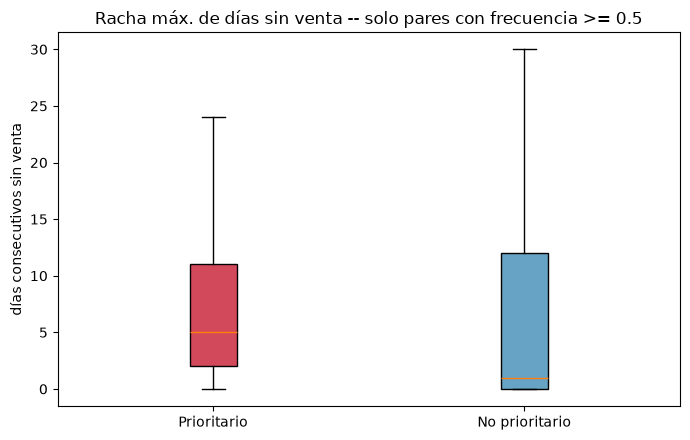

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
grupos_g = ['Prioritario', 'No prioritario']
datos_box = [alta_frecuencia.loc[alta_frecuencia['es_prioritario'] == (g == 'Prioritario'), 'racha_max_ceros'] for g in grupos_g]
bp = ax.boxplot(datos_box, showfliers=False, patch_artist=True)
ax.set_xticks([1, 2]); ax.set_xticklabels(grupos_g)
for patch, color in zip(bp['boxes'], [COLOR_PRIORITARIO, COLOR_NO_PRIORITARIO]):
    patch.set_facecolor(color)
ax.set_title(f"Racha máx. de días sin venta -- solo pares con frecuencia >= {PARAMS['UMBRAL_FRECUENCIA_RACHA_CONTROL']}")
ax.set_ylabel('días consecutivos sin venta')
plt.tight_layout()
plt.show()


Restringido a alta frecuencia, una racha corta es lo esperable -- los
valores altos que sobrevivan este filtro sí son candidatos genuinos a
quiebre de stock histórico, no simple baja rotación.

In [14]:
candidatos_quiebre = alta_frecuencia.loc[alta_frecuencia['racha_max_ceros'] >= alta_frecuencia['racha_max_ceros'].quantile(0.9)]
candidatos_quiebre = candidatos_quiebre.merge(dim_producto[['codigo_item', 'nombre', 'categoria']], on='codigo_item').sort_values('racha_max_ceros', ascending=False)
print(f'{len(candidatos_quiebre)} pares (percentil 90+ de racha, dentro de alta frecuencia) -- candidatos a quiebre histórico documentado:')

# Cruce con estacionalidad_sku (03): una racha larga en un producto muy
# concentrado en navidad/Semana Santa, o en Frutas y verduras (estacionalidad
# agrícola que este dataset no mide con calendario de eventos), probablemente
# es "fuera de temporada", no desabastecimiento.
candidatos_quiebre = candidatos_quiebre.merge(
    estacionalidad_sku[['codigo_item', 'ratio_concentracion_navidad', 'ratio_concentracion_semana_santa']],
    on='codigo_item', how='left'
)
candidatos_quiebre['posible_estacionalidad'] = (
    (candidatos_quiebre['ratio_concentracion_navidad'] > 0.3)
    | (candidatos_quiebre['ratio_concentracion_semana_santa'] > 0.3)
    | (candidatos_quiebre['categoria'] == 'Frutas y verduras')
)
print(f"De esos, {candidatos_quiebre['posible_estacionalidad'].sum()} tienen posible estacionalidad (concentración > 30% en",
      "navidad/Semana Santa, o son Frutas y verduras) -- candidatos MENOS confiables a quiebre real.")
print()
print('Candidatos CONFIABLES (sin señal de estacionalidad):')
confiables = candidatos_quiebre.loc[~candidatos_quiebre['posible_estacionalidad']]
display_cols = ['codigo_item', 'nombre', 'categoria', 'sucursal', 'frecuencia_venta', 'racha_max_ceros']
print(confiables[display_cols].head(10).to_string(index=False))


110 pares (percentil 90+ de racha, dentro de alta frecuencia) -- candidatos a quiebre histórico documentado:
De esos, 5 tienen posible estacionalidad (concentración > 30% en navidad/Semana Santa, o son Frutas y verduras) -- candidatos MENOS confiables a quiebre real.

Candidatos CONFIABLES (sin señal de estacionalidad):
codigo_item                                   nombre        categoria  sucursal  frecuencia_venta  racha_max_ceros
       P424                 FOSFORO REFUEGOS *20UNID            Hogar PRINCIPAL              0.54              130
       P641                    ARROZ SUPREMO *500 GR            Arroz PRINCIPAL              0.60              117
      P2709 CREMA DENT COLGATE TRIPLE * 50 + CEPILLO Cuidado personal PRINCIPAL              0.61              116
      P4359         PAPEL HIG ELITE DUO ROLLAZO *UND       Aseo hogar     LA 21              0.52               72
      P1474              CANELA ASTILLA EL REY *11GR      Condimentos PRINCIPAL              0.58      

In [15]:
print('Candidatos con posible estacionalidad (revisar antes de usar como evidencia de desabastecimiento):')
candidatos_quiebre.loc[candidatos_quiebre['posible_estacionalidad'], ['codigo_item', 'nombre', 'categoria', 'sucursal', 'frecuencia_venta', 'racha_max_ceros', 'ratio_concentracion_navidad', 'ratio_concentracion_semana_santa']].head(10)


Candidatos con posible estacionalidad (revisar antes de usar como evidencia de desabastecimiento):


,codigo_item,nombre,categoria,sucursal,frecuencia_venta,racha_max_ceros,ratio_concentracion_navidad,ratio_concentracion_semana_santa
8,P916,RAPI PAPA *LB,Frutas y verduras,PRINCIPAL,0.54,60,0.10,0.02
64,P1829,NARANJA TANGELO *KL,Frutas y verduras,GLORIETA,0.58,32,0.08,0.03
68,P4100,CHAMPIÑON NATURAL * 250,Frutas y verduras,PRINCIPAL,0.68,31,0.08,0.03
82,P1819,GRANADILLA *UND,Frutas y verduras,PRINCIPAL,0.50,28,0.10,0.03
102,P1829,NARANJA TANGELO *KL,Frutas y verduras,PRINCIPAL,0.57,23,0.08,0.03


In [16]:
# ¿Existen los datos que el nivel 2 de la síntesis (05) va a asumir?
fact_inventario_cols = pd.read_csv(f'{DW}/fact_inventario.csv', nrows=0).columns.tolist()
print('fact_inventario tiene dias_cobertura:', 'dias_cobertura' in fact_inventario_cols)
print('dim_proveedor tiene lead_time_dias:', 'lead_time_dias' in dim_proveedor.columns)
print('-> ambos campos existen; el nivel 2 (clasificador de riesgo) no está bloqueado por falta de datos.')


fact_inventario tiene dias_cobertura: True
dim_proveedor tiene lead_time_dias: True
-> ambos campos existen; el nivel 2 (clasificador de riesgo) no está bloqueado por falta de datos.


In [17]:
# Se exporta racha_df completo (todos los pares, no solo alta frecuencia)
# con grupo_condicion ya resuelto, para que el resto de la cadena pueda
# usar la racha sin reimplementar este cálculo.
racha_df['grupo_condicion'] = racha_df['codigo_item'].map(grupo_condicion)
racha_df.to_parquet(f'{DW}/racha_por_par.parquet', index=False)
print('guardado:', f'{DW}/racha_por_par.parquet', racha_df.shape)


guardado: /home/ddelgadillo@redcorporativa.corpoica.org.co/otros/etl/InventaIO/data/processed_real/racha_por_par.parquet (11135, 6)


## 3. Precio y promoción

`en_promocion` en `fact_ventas` es **siempre `False`** en el dato real --
Siigo no registra explícitamente promociones. `valor_unitario` (que sí
varía) se usa como proxy.

In [18]:
print('en_promocion, valores únicos en fact_ventas:', fact_ventas['en_promocion'].unique())


en_promocion, valores únicos en fact_ventas: [False]


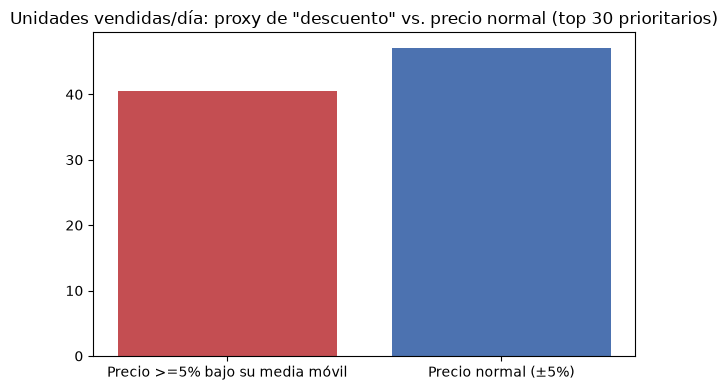

demanda media con proxy de descuento: 40.5 u/día (n=2923 días-producto)
demanda media sin descuento: 47.1 u/día (n=32938 días-producto)


In [19]:
top_valor_prioritarios = valor_por_producto.reindex(prioritarios).sort_values(ascending=False).head(30).index
precio_diario = (
    ventas.loc[ventas['codigo_item'].isin(top_valor_prioritarios)]
    .groupby(['codigo_item', 'fecha'], observed=True)
    .agg(unidades=('cantidad', 'sum'), precio_medio=('valor_unitario', 'mean'))
    .reset_index()
    .sort_values(['codigo_item', 'fecha'])
)
precio_diario['precio_media_movil_28'] = precio_diario.groupby('codigo_item')['precio_medio'].transform(
    lambda s: s.rolling(28, min_periods=10).mean()
)
precio_diario['descuento_pct'] = 1 - precio_diario['precio_medio'] / precio_diario['precio_media_movil_28']
precio_diario = precio_diario.dropna(subset=['descuento_pct'])

con_descuento = precio_diario.loc[precio_diario['descuento_pct'] >= 0.05, 'unidades']
sin_descuento = precio_diario.loc[precio_diario['descuento_pct'].abs() < 0.05, 'unidades']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Precio >=5% bajo su media móvil', 'Precio normal (±5%)'],
       [con_descuento.mean(), sin_descuento.mean()], color=['#c44e52', '#4c72b0'])
ax.set_title('Unidades vendidas/día: proxy de "descuento" vs. precio normal (top 30 prioritarios)')
plt.tight_layout()
plt.show()
print(f'demanda media con proxy de descuento: {con_descuento.mean():.1f} u/día (n={len(con_descuento)} días-producto)')
print(f'demanda media sin descuento: {sin_descuento.mean():.1f} u/día (n={len(sin_descuento)} días-producto)')


El resultado es el **opuesto** al esperado: el proxy de "descuento"
vende *menos*, no más. Probablemente captura cambios de mezcla de
referencias o de proveedor, no una promoción real -- se retira de la lista
de features de prioridad alta para el modelado; queda como feature
exploratoria de baja prioridad.

## 4. Devoluciones

Se excluyen del target de demanda (0,07% de `fact_ventas`) por ser una
señal separada -- decisión ya tomada en INV-60/61. Quedaban sin caracterizar.

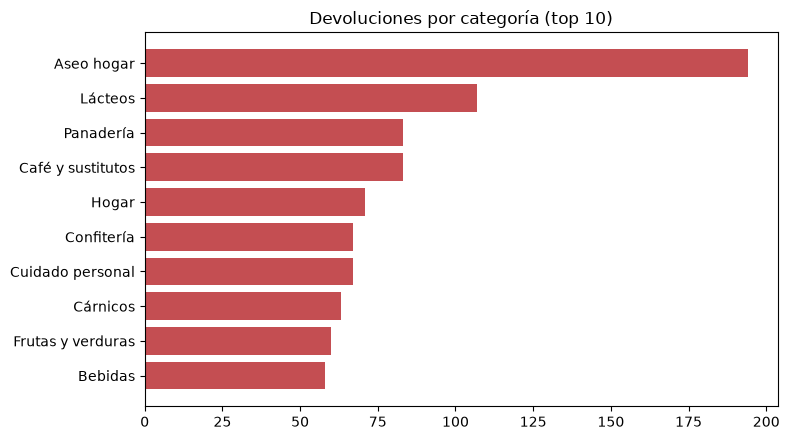

19.2% de las devoluciones son de productos perecederos/refrigerados, vs. 11.7% de esas categorías en el catálogo total.


In [20]:
devoluciones = fact_ventas.loc[fact_ventas['es_devolucion']].copy()
devoluciones = devoluciones.merge(dim_producto[['codigo_item', 'categoria', 'cond2_perecedero', 'cond3_refrigerado']], on='codigo_item', how='left')

por_categoria = devoluciones.groupby('categoria', observed=True).size().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(por_categoria.index[::-1], por_categoria.values[::-1], color='#c44e52')
ax.set_title('Devoluciones por categoría (top 10)')
plt.tight_layout()
plt.show()

pct_perecedero_refrigerado = devoluciones[['cond2_perecedero', 'cond3_refrigerado']].any(axis=1).mean()
pct_catalogo_perecedero_refrigerado = dim_producto[['cond2_perecedero', 'cond3_refrigerado']].any(axis=1).mean()
print(f'{pct_perecedero_refrigerado:.1%} de las devoluciones son de productos perecederos/refrigerados,',
      f'vs. {pct_catalogo_perecedero_refrigerado:.1%} de esas categorías en el catálogo total.')


Las devoluciones **sí se concentran** en perecederos/refrigerados por
encima de su peso en el catálogo -- señal real de calidad/vencimiento, se
recomienda como feature para un clasificador de riesgo de quiebre más
adelante en la cadena.

In [21]:
# Se exporta el diagnóstico de precio y devoluciones a un archivo aparte --
# para que el resto de la cadena lea estos números en vez de recalcularlos.
diagnostico_features_riesgo = {
    'demanda_con_descuento': float(con_descuento.mean()),
    'demanda_sin_descuento': float(sin_descuento.mean()),
    'pct_devoluciones_perecedero_refrigerado': float(pct_perecedero_refrigerado),
    'pct_catalogo_perecedero_refrigerado': float(pct_catalogo_perecedero_refrigerado),
}
with open(f'{DW}/diagnostico_features_riesgo.json', 'w') as f:
    json.dump(diagnostico_features_riesgo, f, indent=2, ensure_ascii=False)
print('guardado:', f'{DW}/diagnostico_features_riesgo.json')
diagnostico_features_riesgo


guardado: /home/ddelgadillo@redcorporativa.corpoica.org.co/otros/etl/InventaIO/data/processed_real/diagnostico_features_riesgo.json


{'demanda_con_descuento': 40.45342319534725,
 'demanda_sin_descuento': 47.12908798348412,
 'pct_devoluciones_perecedero_refrigerado': 0.19170984455958548,
 'pct_catalogo_perecedero_refrigerado': 0.11732973701955496}

## 5. Baseline cuantitativo — naive, seasonal-naive y media móvil, con WAPE

4 orígenes de pronóstico comunes (2 ordinarios, Semana Santa, diciembre
alto), WAPE agregado suma/suma, pares sin venta en el horizonte
conservados (no descartados).

**Alineación del seasonal-naive por día de semana, no por posición**: un
método que compara "7 días hábiles atrás" por posición se desalinea en
cuanto un hueco de calendario cae dentro de esa ventana -- "7 posiciones
atrás" deja de ser "el mismo día de la semana". Verificado: en
`semana_santa`, 11 de 15 días de prueba quedaban comparados contra el día
de semana equivocado (el Viernes Santo, un hueco real, corre el índice).
Se reconstruye buscando, para cada día de prueba, el hábil más reciente
con su mismo día ISO de semana.

**Universo de pares sin mirar al futuro**: exigir `ultima_venta >= origen`
sobre la ventana completa (calculada con información posterior al origen)
es un sesgo de supervivencia que excluye justo los pares que dejaron de
venderse después del origen -- el caso de interés para un sistema de
alerta. Se reconstruye usando solo `diario.loc[fecha < origen]`, con una
ventana de actividad de `PARAMS['VENTANA_ACTIVIDAD_BASELINE_DIAS']` días
**hábiles** (igual que el resto del notebook, no calendario natural).

In [22]:
ORIGENES_BASELINE = {k: pd.Timestamp(v) for k, v in PARAMS['ORIGENES_BASELINE'].items()}
H = PARAMS['HORIZONTE_BASELINE_DIAS']
VENTANA_ESTACIONAL = PARAMS['VENTANA_ESTACIONAL_DIAS']
VENTANA_ACTIVIDAD = PARAMS['VENTANA_ACTIVIDAD_BASELINE_DIAS']

def ventana_habil(origen, dias_atras, dias_adelante):
    idx_o = indice_habil[origen]
    return fechas_habiles[idx_o - dias_atras: idx_o], fechas_habiles[idx_o: idx_o + dias_adelante]

# Diagnóstico de desalineación del método por posición -- se deja como
# evidencia documentada de por qué se rediseñó el seasonal-naive.
for nombre, fecha in PARAMS['ORIGENES_BASELINE'].items():
    origen = pd.Timestamp(fecha)
    tt, td = ventana_habil(origen, VENTANA_ESTACIONAL, H)
    desalineados = sum(tt[i % VENTANA_ESTACIONAL].isoweekday() != td[i].isoweekday() for i in range(H))
    print(f'{nombre}: {desalineados} de {H} días quedarían comparados contra el día de semana equivocado (método por posición, ya no se usa).')


ordinario_1: 0 de 15 días quedarían comparados contra el día de semana equivocado (método por posición, ya no se usa).
ordinario_2: 0 de 15 días quedarían comparados contra el día de semana equivocado (método por posición, ya no se usa).
semana_santa: 11 de 15 días quedarían comparados contra el día de semana equivocado (método por posición, ya no se usa).
diciembre_alto: 0 de 15 días quedarían comparados contra el día de semana equivocado (método por posición, ya no se usa).


In [23]:
# Seasonal-naive por DÍA DE SEMANA -- busca, para cada fecha de prueba,
# el hábil más reciente con su mismo isoweekday, sin límite fijo de "7 atrás".
def fechas_por_dow_antes_de(origen, minimo_dow=7, tope_busqueda=30):
    idx_o = indice_habil[origen]
    encontrados = {}
    j = idx_o - 1
    intentos = 0
    while len(encontrados) < minimo_dow and j >= 0 and intentos < tope_busqueda:
        f = fechas_habiles[j]
        dow = f.isoweekday()
        if dow not in encontrados:
            encontrados[dow] = f
        j -= 1
        intentos += 1
    return encontrados

fechas_necesarias = set()
for origen in ORIGENES_BASELINE.values():
    idx_o = indice_habil[origen]
    _, test_dates = ventana_habil(origen, VENTANA_ESTACIONAL, H)
    fechas_necesarias.update(test_dates)
    fechas_necesarias.update(fechas_habiles[idx_o - VENTANA_ESTACIONAL: idx_o])
    fechas_necesarias.update(fechas_por_dow_antes_de(origen).values())
fechas_necesarias = sorted(fechas_necesarias)


In [24]:
# Universo de pares "vivos" SIN mirar al futuro -- última/primera venta
# calculadas solo con diario.loc[fecha < origen], sobre calendario hábil.
def pares_vivos_en_origen(origen):
    idx_o = indice_habil[origen]
    antes = diario.loc[diario['fecha'] < origen]
    rango = antes.groupby(['codigo_item', 'sucursal'], observed=True)['fecha'].agg(primera='min', ultima='max')
    idx_primera = rango['primera'].map(indice_habil)
    idx_ultima = rango['ultima'].map(indice_habil)
    return rango.loc[(idx_o - idx_ultima <= VENTANA_ACTIVIDAD) & (idx_o - idx_primera >= PARAMS['MIN_DIAS_TRAIN_BASELINE'])]

pares_vivos_por_origen = {n: pares_vivos_en_origen(o) for n, o in ORIGENES_BASELINE.items()}
universo_pares = set()
for vivos in pares_vivos_por_origen.values():
    universo_pares.update(vivos.index)
universo_index = pd.MultiIndex.from_tuples(sorted(universo_pares), names=['codigo_item', 'sucursal'])

wide = diario.loc[diario['fecha'].isin(fechas_necesarias)].pivot_table(
    index=['codigo_item', 'sucursal'], columns='fecha', values='unidades', aggfunc='sum', fill_value=0
)
wide = wide.reindex(index=universo_index, columns=fechas_necesarias, fill_value=0)
print(f'universo de pares vivos en algún origen (sin mirar al futuro): {len(universo_index)} | tabla ancha: {wide.shape}')


universo de pares vivos en algún origen (sin mirar al futuro): 8947 | tabla ancha: (8947, 88)


In [25]:
def evaluar_origen(nombre_origen, origen):
    idx_o = indice_habil[origen]
    _, test_dates = ventana_habil(origen, VENTANA_ESTACIONAL, H)
    tail_dates = fechas_habiles[idx_o - VENTANA_ESTACIONAL: idx_o]
    fechas_dow = fechas_por_dow_antes_de(origen)

    vivos = pares_vivos_por_origen[nombre_origen]
    idx_vivos = pd.MultiIndex.from_tuples(vivos.index.tolist(), names=['codigo_item', 'sucursal']).intersection(wide.index)
    if len(idx_vivos) == 0:
        return pd.DataFrame()

    tail = wide.loc[idx_vivos, tail_dates].values
    actual = wide.loc[idx_vivos, test_dates].values

    pred_naive = np.repeat(tail[:, -1:], H, axis=1)
    pred_media_movil = np.repeat(tail.mean(axis=1, keepdims=True), H, axis=1)
    cols_dow = [fechas_dow[f.isoweekday()] for f in test_dates]
    pred_estacional = wide.loc[idx_vivos, cols_dow].values

    df = pd.DataFrame({
        'codigo_item': [c for c, s in idx_vivos], 'sucursal': [s for c, s in idx_vivos], 'origen': nombre_origen,
        'actual_sum': actual.sum(axis=1),
        'abs_err_naive_diario': np.abs(actual - pred_naive).sum(axis=1),
        'abs_err_estacional_diario': np.abs(actual - pred_estacional).sum(axis=1),
        'abs_err_media_movil_diario': np.abs(actual - pred_media_movil).sum(axis=1),
        'pred_naive_horizonte': pred_naive.sum(axis=1),
        'pred_estacional_horizonte': pred_estacional.sum(axis=1),
        'pred_media_movil_horizonte': pred_media_movil.sum(axis=1),
    })
    df['abs_err_naive_horizonte'] = (df['actual_sum'] - df['pred_naive_horizonte']).abs()
    df['abs_err_estacional_horizonte'] = (df['actual_sum'] - df['pred_estacional_horizonte']).abs()
    df['abs_err_media_movil_horizonte'] = (df['actual_sum'] - df['pred_media_movil_horizonte']).abs()
    return df

baseline_df = pd.concat([evaluar_origen(n, o) for n, o in ORIGENES_BASELINE.items()], ignore_index=True)
baseline_df = baseline_df.merge(adi_cv2[['codigo_item', 'sucursal', 'patron']], on=['codigo_item', 'sucursal'], how='left')
baseline_df = baseline_df.merge(prioridad_par[['codigo_item', 'sucursal', 'es_prioritario']], on=['codigo_item', 'sucursal'], how='left')

n_sin_venta_horizonte = (baseline_df['actual_sum'] == 0).sum()
n_pares_evaluados = baseline_df[['codigo_item', 'sucursal']].drop_duplicates().shape[0]  # pares producto x sucursal, no códigos de producto
print(f'{len(baseline_df)} evaluaciones par-origen ({n_pares_evaluados} pares distintos de {len(universo_index)} en el universo,',
      f'{baseline_df["codigo_item"].nunique()} productos distintos, {len(ORIGENES_BASELINE)} orígenes)')
print(f'{n_sin_venta_horizonte} ({n_sin_venta_horizonte/len(baseline_df):.1%}) no vendieron nada en su horizonte de evaluación -- CONSERVADOS.')


29142 evaluaciones par-origen (8947 pares distintos de 8947 en el universo, 3885 productos distintos, 4 orígenes)
9121 (31.3%) no vendieron nada en su horizonte de evaluación -- CONSERVADOS.


In [26]:
BASELINES = ['naive', 'estacional', 'media_movil']

def wape_agregado(grupo, col_err):
    return grupo[col_err].sum() / grupo['actual_sum'].sum()

def tabla_wape_por(columna_grupo):
    return baseline_df.groupby(columna_grupo).apply(
        lambda g: pd.Series({
            f'wape_{b}_{vista}': wape_agregado(g, f'abs_err_{b}_{vista}')
            for b in BASELINES for vista in ('diario', 'horizonte')
        }), include_groups=False
    ).round(3)

resumen_por_origen = tabla_wape_por('origen')
resumen_por_origen


,wape_naive_diario,wape_naive_horizonte,wape_estacional_diario,wape_estacional_horizonte,wape_media_movil_diario,wape_media_movil_horizonte
origen,,,,,,
diciembre_alto,1.00,0.79,0.98,0.49,0.90,0.49
ordinario_1,1.02,0.80,0.99,0.47,0.89,0.46
ordinario_2,1.03,0.85,1.05,0.49,0.94,0.48
semana_santa,1.11,0.85,1.00,0.46,0.89,0.46


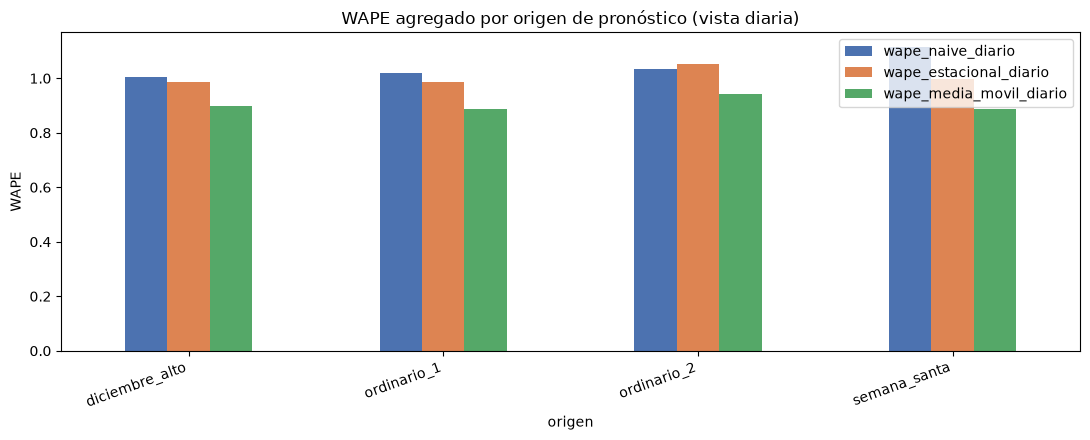

peor origen: semana_santa (WAPE 1.11) | mejor origen: diciembre_alto (1.00)


In [27]:
fig, ax = plt.subplots(figsize=(11, 4.5))
resumen_por_origen[[f'wape_{b}_diario' for b in BASELINES]].plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452', '#55a868'])
ax.set_title('WAPE agregado por origen de pronóstico (vista diaria)')
ax.set_ylabel('WAPE')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
peor_origen = resumen_por_origen['wape_naive_diario'].idxmax()
mejor_origen = resumen_por_origen['wape_naive_diario'].idxmin()
print(f'peor origen: {peor_origen} (WAPE {resumen_por_origen.loc[peor_origen, "wape_naive_diario"]:.2f})',
      f'| mejor origen: {mejor_origen} ({resumen_por_origen.loc[mejor_origen, "wape_naive_diario"]:.2f})')


Un modelo naive validado solo en meses ordinarios se cae justo en el
período que más le importa al negocio -- Semana Santa concentra el peor
desempeño, diciembre alto el mejor. No es aleatorio: se cruza con el
efecto de calendario medido en el notebook anterior en la celda
siguiente.

In [28]:
# ¿El peor origen coincide con el efecto de calendario más fuerte fuera de diciembre?
if peor_origen == 'semana_santa':
    fila_ss = efectos_calendario.loc[efectos_calendario['evento'].str.contains('Semana Santa', case=False, na=False)]
    if len(fila_ss):
        f = fila_ss.iloc[0]
        print(f'El 03 midió Semana Santa como {f["controlado_x"]:.2f}x (IC [{f["ic_bajo"]:.2f}, {f["ic_alto"]:.2f}]) --',
              'el efecto de calendario más fuerte fuera del bloque de diciembre. Que el baseline se caiga justo ahí',
              'no es casualidad: es la disrupción de demanda más grande que ningún baseline sin features de',
              'calendario puede capturar -- confirma que 05 necesita una feature explícita de Semana Santa, no',
              'solo día de semana + tendencia.')


El 03 midió Semana Santa como 1.36x (IC [1.24, 1.50]) -- el efecto de calendario más fuerte fuera del bloque de diciembre. Que el baseline se caiga justo ahí no es casualidad: es la disrupción de demanda más grande que ningún baseline sin features de calendario puede capturar -- confirma que 05 necesita una feature explícita de Semana Santa, no solo día de semana + tendencia.


In [29]:
gana_estacional = (resumen_por_origen['wape_estacional_diario'] < resumen_por_origen['wape_media_movil_diario'])
print(resumen_por_origen[['wape_naive_diario', 'wape_estacional_diario', 'wape_media_movil_diario']])
print()
print(f'seasonal-naive le gana a media móvil en {gana_estacional.sum()} de {len(gana_estacional)} orígenes.')


                wape_naive_diario  wape_estacional_diario  \
origen                                                      
diciembre_alto               1.00                    0.98   
ordinario_1                  1.02                    0.99   
ordinario_2                  1.03                    1.05   
semana_santa                 1.11                    1.00   

                wape_media_movil_diario  
origen                                   
diciembre_alto                     0.90  
ordinario_1                        0.89  
ordinario_2                        0.94  
semana_santa                       0.89  

seasonal-naive le gana a media móvil en 0 de 4 orígenes.


Seasonal-naive **no le gana** a media móvil en ningún origen -- la
ventaja que tenía sobre naive era mayormente promediar 7 días, no
periodicidad semanal real explotable por SKU individual. El piso de
comparación para cualquier modelo candidato debe ser media móvil, no
seasonal-naive.

In [30]:
# En vista HORIZONTE (suma sobre los 15 días, no error día a día) ambos
# métodos convergen -- con más decimales se ve que no son idénticos, solo
# muy cercanos.
comp_horizonte = resumen_por_origen[['wape_estacional_horizonte', 'wape_media_movil_horizonte']].round(4)
print(comp_horizonte)
diferencia_horizonte = (comp_horizonte['wape_estacional_horizonte'] - comp_horizonte['wape_media_movil_horizonte']).abs()
print()
print(f'diferencia absoluta máxima entre métodos, vista horizonte: {diferencia_horizonte.max():.4f}')


                wape_estacional_horizonte  wape_media_movil_horizonte
origen                                                               
diciembre_alto                       0.49                        0.49
ordinario_1                          0.47                        0.46
ordinario_2                          0.49                        0.48
semana_santa                         0.46                        0.46

diferencia absoluta máxima entre métodos, vista horizonte: 0.0090


**Motivo aritmético de la cercanía**: en vista horizonte el error se
mide sobre la suma de 15 días -- más de 2 ventanas estacionales completas
de 7 días -- así que tanto el seasonal-naive (que repite un patrón
semanal) como la media móvil (una constante) terminan sumando algo muy
cercano a 15/7 veces la suma semanal típica. La vista horizonte diluye la
periodicidad intra-semana que sí distingue a los métodos en la vista
diaria -- por eso es la vista diaria, no la de horizonte, la que debe
gobernar la elección de baseline para el modelado.

/tmp/ipykernel_3584586/3714148686.py:4: RuntimeWarning: invalid value encountered in scalar divide
  return grupo[col_err].sum() / grupo['actual_sum'].sum()


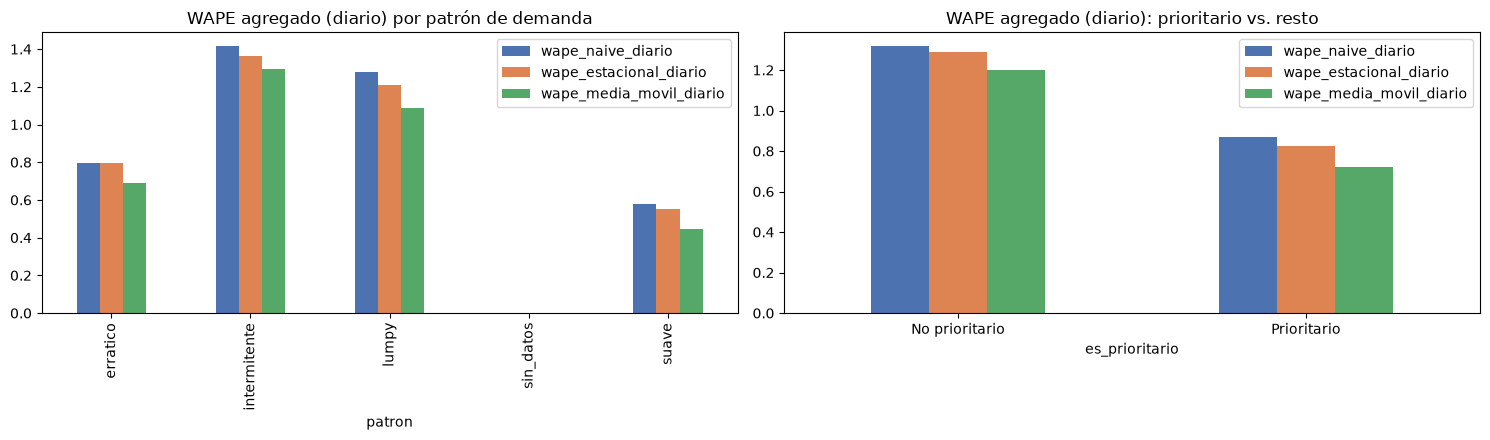

              wape_naive_diario  wape_naive_horizonte  wape_estacional_diario  \
patron                                                                          
erratico                   0.80                  0.50                    0.80   
intermitente               1.42                  1.27                    1.36   
lumpy                      1.28                  1.03                    1.21   
sin_datos                   NaN                   NaN                     NaN   
suave                      0.58                  0.37                    0.55   

              wape_estacional_horizonte  wape_media_movil_diario  \
patron                                                             
erratico                           0.37                     0.69   
intermitente                       0.70                     1.29   
lumpy                              0.57                     1.09   
sin_datos                           NaN                      NaN   
suave                   

In [31]:
tabla_wape_patron = tabla_wape_por('patron')
tabla_wape_prior = tabla_wape_por('es_prioritario')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
tabla_wape_patron[[f'wape_{b}_diario' for b in BASELINES]].plot(kind='bar', ax=axes[0], color=['#4c72b0', '#dd8452', '#55a868'])
axes[0].set_title('WAPE agregado (diario) por patrón de demanda')
tabla_wape_prior[[f'wape_{b}_diario' for b in BASELINES]].plot(kind='bar', ax=axes[1], color=['#4c72b0', '#dd8452', '#55a868'])
axes[1].set_xticklabels(['No prioritario', 'Prioritario'], rotation=0)
axes[1].set_title('WAPE agregado (diario): prioritario vs. resto')
plt.tight_layout()
plt.show()
print(tabla_wape_patron)
print()
print(tabla_wape_prior)


Con WAPE agregado (ponderado por volumen, no mediana por serie) esta
comparación refleja dónde se concentra el error real de negocio -- es el
piso contra el que debe compararse cualquier modelo candidato (LightGBM,
Croston, TSB) más adelante en el proyecto.

## 6. Verificación y salidas para la cadena

In [32]:
assert set(zip(baseline_df['codigo_item'], baseline_df['sucursal'])).issubset(set(zip(ventana['codigo_item'], ventana['sucursal']))), \
    'el baseline evaluó pares fuera del universo calculado en ventana'
assert adi_cv2['patron'].isin(['suave', 'intermitente', 'erratico', 'lumpy', 'sin_datos']).all()
print('Invariantes verificadas OK.')

patron_demanda_producto_sucursal = adi_cv2.merge(
    adi_cv2_semanal[['codigo_item', 'sucursal', 'adi', 'cv2', 'patron']],
    on=['codigo_item', 'sucursal'], suffixes=('_diario', '_semanal'), how='left'
)
patron_demanda_producto_sucursal.to_parquet(f'{DW}/patron_demanda_producto_sucursal.parquet', index=False)
baseline_df.to_parquet(f'{DW}/baseline_wape.parquet', index=False)
print('guardado: patron_demanda_producto_sucursal.parquet', patron_demanda_producto_sucursal.shape)
print('guardado: baseline_wape.parquet', baseline_df.shape)


Invariantes verificadas OK.
guardado: patron_demanda_producto_sucursal.parquet (11135, 10)
guardado: baseline_wape.parquet (29142, 15)


In [33]:
huella = {
    'notebook': '04_demanda_y_baseline',
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'entradas': registrar_huella([
        'dim_sucursal.csv', 'dim_proveedor.csv', 'fact_ventas.csv', 'fact_inventario.csv',
        'panel_diario.parquet', 'ventana_activa.parquet', 'huecos_calendario.csv', 'calendario_habil.csv',
        'dim_producto_priorizado.parquet', 'priorizacion_producto_sucursal.parquet',
    ]),
    'salidas': registrar_huella([
        'patron_demanda_producto_sucursal.parquet', 'baseline_wape.parquet',
        'estacionalidad_indices_dia_semana_patron.csv',
        'racha_por_par.parquet', 'diagnostico_features_riesgo.json',
    ]),
}
with open(f'{DW}/huella_04.json', 'w') as f:
    json.dump(huella, f, indent=2, ensure_ascii=False)
print('guardado: huella_04.json')
huella


guardado: huella_04.json


{'notebook': '04_demanda_y_baseline',
 'fecha_generacion': '2026-09-24T16:26:27.636301',
 'entradas': {'dim_sucursal.csv': 'fd1a2f5274d5',
  'dim_proveedor.csv': '589ae5214b01',
  'fact_ventas.csv': 'fb35feee9fba',
  'fact_inventario.csv': 'ca5a60a2a26f',
  'panel_diario.parquet': 'ec185240431c',
  'ventana_activa.parquet': 'ba81966d0dbc',
  'huecos_calendario.csv': '147fa472f8b6',
  'calendario_habil.csv': '8fc852b60db6',
  'dim_producto_priorizado.parquet': '8507a3d2e212',
  'priorizacion_producto_sucursal.parquet': 'e362568c6724'},
 'salidas': {'patron_demanda_producto_sucursal.parquet': '1b4d4bcb9ad8',
  'baseline_wape.parquet': '1fb32082d516',
  'estacionalidad_indices_dia_semana_patron.csv': 'e9539d16b1c9',
  'racha_por_par.parquet': '554d205f40b3',
  'diagnostico_features_riesgo.json': '75951672a76f'}}